In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
from IPython.display import clear_output
import matplotlib.pyplot as plt
from torch.distributions import Normal

Classe do ambiente

In [2]:
# class TankEnv:

#     def __init__(self, setpoint, n_states):
#         self.setpoint  = setpoint
#         self.max_h     = 100.0
#         self.A         = 20.0
#         self.dt        = 1.0
#         self.n_states  = n_states


#         self.q_actions = [0.0, 5, 10.0]
#         self.k         = self.q_actions[1] / np.sqrt(self.setpoint)
#         self.n_actions = len(self.q_actions)
#         print(self.k)
#         self.h           = 0.0
#         self.last_action = 1

#     def reset(self):
#         self.h = np.random.uniform(0.0, 100.0)
#         self.last_action = 1

#         return self.get_state()

#     def get_state(self):
#         bin_size = self.max_h / self.n_states
#         state    = int(np.clip(self.h // bin_size, 0, self.n_states - 1))
#         return state

#     def step(self, action):
#         q_in  = self.q_actions[action]
        
#         q_out = self.k * np.sqrt(max(self.h, 0.0))

#         dh    = (q_in - q_out) / self.A
#         self.h = np.clip(self.h + dh * self.dt, 0, self.max_h)

#         error  = abs(self.h - self.setpoint)
#         #reward = -(error ** 2) / 2500.0

#         # reward = (-(error)-(0.8*q_in)) / 50.0

#         reward = -(error) / 50.0
        
#         # if error < 2.5 and q_in == 5.0:
#         #     reward += 1.0

#         # if error < 2.5:
#         #     reward += 1.0

#         self.last_action = action
#         next_state       = self.get_state()
#         done             = False

#         return next_state, reward, done, {"h": self.h, "error": error}

In [3]:
class TankEnv:

    def __init__(self, setpoint):

        self.setpoint = setpoint

        self.max_h = 100.0

        self.A = 20.0

        self.dt = 1.0

        self.max_q_in = 10.0

        self.k = 5.0 / np.sqrt(setpoint)

        self.state_dim = 1

        self.action_dim = 1

        self.h = 0.0

        self.max_steps = 200

        self.steps = 0

    def _get_normalized_state(self):
        """
        Normaliza o estado para o intervalo [-1, 1].
        Isso é crucial para a estabilidade da Rede Neural.
        """
        # (h - 50) / 50 -> resulta em -1 para h=0, e 1 para h=100
        norm_h = (self.h - self.setpoint) / (self.max_h / 2.0)
        return np.array([norm_h], dtype=np.float32)
    
    def reset(self):

        # self.h = np.random.uniform(0.0, self.max_h)
        self.h = 0
        self.steps = 0

        state = np.array([self.h], dtype=np.float32)

        return state
   
    def step(self, action):

        self.steps += 1

        q_in = np.clip(float(action), 0.0, self.max_q_in)

        
        q_out = self.k * np.sqrt(max(self.h, 0.0))

        dh = (q_in - q_out) / self.A

        self.h = np.clip(
            self.h + dh * self.dt,
            0.0,
            self.max_h
        )

        error = abs(self.h - self.setpoint)

        if error <= 2.5:
            # Recompensa positiva por manter o sistema dentro da tolerância
            reward = 1.0 
        else:
            # Punição linear normalizada pelo erro máximo possível (50.0)
            reward = - (error / 50.0)

        done = self.steps >= self.max_steps

        

        info = {
            "h": self.h,
            "q_in": q_in,
            "error": error
        }

        return self._get_normalized_state(), reward, done, info

In [4]:
class Policy(nn.Module):
    ##########################################
    def __init__(self, state_size, action_size, hidden_size=32):
        super(Policy, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.mu_head = nn.Linear(hidden_size, action_size)
        self.log_std = nn.Parameter(torch.zeros(action_size))

    ##########################################
    def forward(self, state):
        x = F.relu(self.fc1(state))
        mu = self.mu_head(x)
        std = self.log_std.exp()
        return mu, std

    ##########################################
    def act(self, state, device):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        # saida da rede é a probabilidade de cada ação para o estado
        mu, std = self.forward(state)
        # escolhe a ação aleatoria segundo a probabilidade categorical
        dist = Normal(mu, std)
        action = dist.sample()
        # retorna ação e log da probabilidade dela
        log_prob = dist.log_prob(action)
        return action.item(), log_prob

In [5]:
class StateValue(nn.Module):
    ##########################################
    def __init__(self, state_size, hidden_size=64):
        super(StateValue, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 1)

    ##########################################
    def forward(self, state):
        x = F.relu(self.fc1(state))
        return self.fc2(x)
    
    ##########################################
    def val(self, state, device):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        return self(state)

In [6]:
# class ActorCritic(object):
#     def __init__(self, parameters):
        
#         self.parameters = parameters

#         # numero de episodios
#         self.episode = 0
        
#         # parametros de aprendizado
#         self.gamma = parameters['gamma']
#         self.alpha = parameters['alpha']
#         self.beta  = parameters['beta']
#         self.device = parameters['device']

                        
#         self.env = TankEnv(setpoint=50)
        

#         # cria as funções parametricas da política e do valor
#         self.critic = StateValue(self.env.observation_space.shape[0]).to(self.device)
#         self.actor  = Policy(self.env.observation_space.shape[0], self.env.action_space.shape[0]).to(self.device)


#         # otimizadores das redes neurais
#         self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=self.alpha)
#         self.actor_optimizer  = optim.Adam(self.actor.parameters(), lr=self.beta)


In [7]:
class ActorCritic(object):
    def __init__(self, parameters):
        self.parameters = parameters
        self.episode = 0
        
        self.gamma  = parameters['gamma']
        self.alpha  = parameters['alpha']
        self.beta   = parameters['beta']
        self.device = parameters['device']

        # 1. Instanciando o Ambiente Customizado
        self.env = TankEnv(setpoint=50.0)
        
        # 2. Instanciando as Redes Neurais (1 entrada contínua, 1 saída contínua)
        state_dim = 1
        action_dim = 1
        
        self.critic = StateValue(state_dim).to(self.device)
        self.actor  = Policy(state_dim, action_dim).to(self.device)

        # 3. Otimizadores
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=self.alpha)
        self.actor_optimizer  = optim.Adam(self.actor.parameters(), lr=self.beta)

    def run_episode(self):
        self.episode += 1
        rewards = []
        I = 1.0
        
        # O reset agora retorna apenas o estado, sem o dicionário 'info'
        S = self.env.reset()

        while True:
            # O Ator amostra uma vazão contínua da distribuição Gaussiana
            A, lp = self.actor.act(S, self.device)

            # O passo na planta (sem 'truncated' ou 'info' do Gymnasium)
            Sl, R, done, info = self.env.step(A)
            rewards.append(R)

            # Avaliação do Crítico para os estados atual e futuro
            vSw  = self.critic.val(S, self.device)
            vSlw = self.critic.val(Sl, self.device)
            
            # Cálculo do Erro TD (Diferença Temporal)
            # O detach() isola o vSlw do grafo de gradientes
            td_target = R + (1 - int(done)) * self.gamma * vSlw.detach()
            td_error  = td_target - vSw
            
            # Função de perda do Crítico (MSE)
            critic_loss = F.mse_loss(vSw, td_target)
            
            # Atualização do Crítico
            self.critic_optimizer.zero_grad()
            critic_loss.backward()
            self.critic_optimizer.step()
            
            # Função de perda do Ator
            actor_loss = -lp * I * td_error.detach()
            
            # Atualização do Ator
            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            self.actor_optimizer.step()

            if done: 
                break

            # Prepara para o próximo loop
            I *= self.gamma
            S = Sl
            
        return np.sum(rewards)

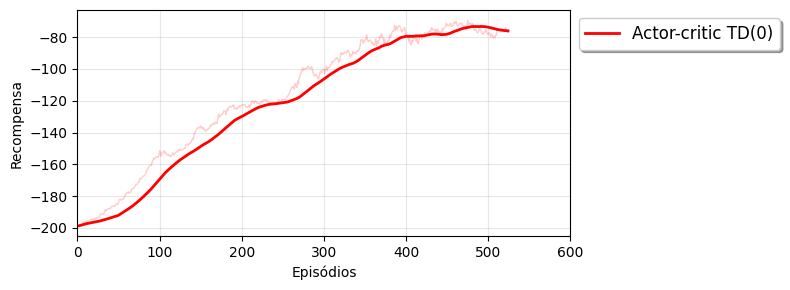

In [ ]:
if __name__ == '__main__':
  
  
    env = TankEnv(setpoint=50)
    # step = 0
    # state = env.reset() 
   
    # time = []
    # level = []
    # for i in range(0, 2500):
    #     action = 5.0
    #     next_state, reward, done, info = env.step(action)
    #     level.append(info["h"])
    #     time.append(i)
        
   
    # plt.plot(time, level)
    
    plt.ion()
    plt.rcParams['figure.figsize'] = (8,3)
    plt.figure(1)
    
    # parametros
    parameters = {'episodes'  : 600,
                  'gamma'     : 0.99,
                  'alpha'     : 2e-3,
                  'beta'      : 1e-3,
                  'device'    : torch.device("cuda:0" if torch.cuda.is_available() else "cpu"),
                  'render'    : False,
                  'nagents'   : 10,
                 }
    
    # historico dos reforços
    rewards_ac = []
    avg_ac = []
    
    # cria 'n_agents' para observar comportamento médio
    acs = [ActorCritic(parameters) for _ in range(parameters['nagents'])]
    
    # loop principal
    for i in range(parameters['episodes']):

        # roda um episodio e armazena a média de todos os agentes
        rewards_ac.append(np.mean( [ac.run_episode() for ac in acs] ))

        # reward medio
        avg_ac.append(np.mean(rewards_ac[-50:]))

        clear_output(wait=True)
        plt.clf()
        plt.plot(rewards_ac, 'r', alpha=0.2, linewidth=1)
        plt.plot(avg_ac, 'r', linewidth=2, label='Actor-critic TD(0)')
        #
        plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fancybox=True, shadow=True, fontsize=12, facecolor='w')
        plt.xlabel('Episódios')
        plt.ylabel('Recompensa')
        plt.xlim([0, parameters['episodes']])
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.gcf().patch.set_alpha(0)
        plt.show()
        plt.pause(.1)

    plt.ioff()